# 00 — cal-disp calibration walkthrough (F08882 golden case)

Stage-by-stage reproduction of `cal_disp.workflow.run_calibration` on the golden dataset, calling the
**same** cal-disp / Venti functions the workflow calls (including the private `_helpers` of
`workflow.py`), so every intermediate result can be inspected. The notebook ends with two tests:

1. the product built here vs the **golden product** in `golden_output/` (the comparison `cal-disp validate`
   runs, plus an independent NaN-aware numeric check), and
2. the product built here vs a product produced by **`cal-disp run`** on the same inputs (bit-for-bit;
   proves the notebook mirrors the workflow).

**How to run**

* `CAL_DISP_GOLDEN_DIR` — root of the golden dataset (`input_data/`, `configs/`, `golden_output/`);
  default `<repo>/test_golden`. Nothing is written into it.
* `TMPDIR` — outputs go to `$TMPDIR/cal_disp_notebooks/00_walkthrough/` (default `<repo>/tmp/...`);
  the `notebook/` and `cli/` sub-folders are wiped at the start of each run.
* Set `NUMPY_MADVISE_HUGEPAGE=0` (done in the first cell if unset) on hosts with fragmented transparent huge pages.
* Kernel: the cal-disp environment (`PYTHONPATH=<repo>/src` if cal-disp is installed from another checkout).
* Runtime ≈ 10-13 min (one workflow in the notebook + one `cal-disp run`, each ≈ 3-6 min depending on host load); peak memory ≈ 18 GB.

```
CAL_DISP_GOLDEN_DIR=/path/to/test_golden NUMPY_MADVISE_HUGEPAGE=0 PYTHONPATH=$PWD/src \
  jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=1800 \
  docs/notebooks/00_calibration_walkthrough.ipynb
```

In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks" / "00_walkthrough"; SCRATCH.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("NUMPY_MADVISE_HUGEPAGE", "0")   # must precede the first numpy import
os.environ.setdefault("TQDM_DISABLE", "1")             # no Venti progress bars in the cell outputs

import logging
import shutil
import sys
import time
from contextlib import ExitStack

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import xarray as xr

import cal_disp
from cal_disp._version import __version__ as cal_disp_pkg_version

# Console logging to stdout so the workflow's own INFO messages appear under each stage
logging.basicConfig(level=logging.INFO, stream=sys.stdout, force=True,
                    format="%(name)s %(levelname)s: %(message)s")
for name in ("cal_disp", "venti"):
    logging.getLogger(name).setLevel(logging.INFO)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
plt.rcParams["figure.dpi"] = 80

T0 = time.perf_counter()
_timings = {}
def stage_done(name):
    _timings[name] = time.perf_counter() - T0
    print(f"[{name}] elapsed since start: {_timings[name]:.0f} s")

# Fresh scratch: the workflow's caches (GNSS .npy, tropo GeoTIFFs) must not leak between runs
for sub in ("notebook", "cli"):
    shutil.rmtree(SCRATCH / sub, ignore_errors=True)

print("repo     :", REPO)
print("cal_disp :", cal_disp.__path__[0], "version", cal_disp_pkg_version)
if len(cal_disp.__path__) > 1:
    # cal_disp has no __init__.py (namespace package): a module missing from this checkout would be
    # imported from the next path on sys.path (e.g. the editable install of another checkout)
    print("NOTE: cal_disp is also found at", list(cal_disp.__path__)[1:])
print("golden   :", GOLDEN, "(exists)" if GOLDEN.exists() else "(MISSING)")
print("scratch  :", SCRATCH)
print("NUMPY_MADVISE_HUGEPAGE =", os.environ["NUMPY_MADVISE_HUGEPAGE"])

repo     : /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp
cal_disp : /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/src/cal_disp version 0.2.post1.dev62+g4117f9341.d20260930
golden   : /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden (exists)
scratch  : /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough
NUMPY_MADVISE_HUGEPAGE = 0


In [2]:
# Plot / print helpers used throughout (decimated rasters keep the notebook small)
DEC = 12                   # every 12th pixel -> ~650 x 790 for a DISP-S1 frame
EXTENT_KM = None           # set once the DISP grid is known

def stats(name, arr, units=""):
    a = np.asarray(arr)
    finite = np.isfinite(a) if a.dtype.kind == "f" else np.ones(a.shape, bool)
    v = a[finite]
    line = f"{name:<22s} shape={a.shape} dtype={a.dtype} finite={finite.mean():6.1%}"
    if v.size:
        line += f"  min={v.min():.6g} max={v.max():.6g} mean={v.mean():.6g} std={v.std():.4g} {units}"
    print(line)

def show(ax, arr, title, units="mm", scale=1e3, cmap="RdBu_r", sym=True, vmin=None, vmax=None, dec=DEC):
    a = np.asarray(arr, dtype=np.float32)[::dec, ::dec] * scale
    if vmin is None or vmax is None:
        if sym:
            v = float(np.nanpercentile(np.abs(a), 98)) or 1.0
            vmin, vmax = -v, v
        else:
            vmin, vmax = (float(p) for p in np.nanpercentile(a, [2, 98]))
    im = ax.imshow(a, cmap=cmap, vmin=vmin, vmax=vmax, extent=EXTENT_KM, interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("easting [km]"); ax.set_ylabel("northing [km]")
    plt.colorbar(im, ax=ax, shrink=0.75, label=units)
    return im

## 0. Setup — configuration the way `cal-disp run` loads it

`cli/run.py::run_main` reads the PGE `RunConfig` from YAML, converts it to a `CalibrationWorkflow`
(`to_workflow()` resolves the paths) and hands it to `main.run`, which prints the summary, validates,
creates the directories and loads `AlgorithmParameters` from the file named in the runconfig.

The golden runconfig is written with paths relative to the *parent* of the golden folder (see
`scripts/build_golden_output.sh`) and points its outputs into the golden folder itself, which is read-only
here. A copy is written to the scratch dir with absolute input paths and redirected output / scratch
directories; the same helper is reused for the `cal-disp run` comparison at the end.

In [3]:
from ruamel.yaml import YAML

from cal_disp.config._algorithm import AlgorithmParameters
from cal_disp.config.pge_runconfig import RunConfig

def write_runconfig(out_dir: Path) -> Path:
    # The golden runconfig's relative paths start with the golden folder's own name
    yaml = YAML(typ="safe"); yaml.default_flow_style = False
    with open(GOLDEN / "configs" / "runconfig.yaml") as f:
        cfg = yaml.load(f)
    root = cfg["cal_disp_workflow"]

    def _abs(p):
        p = Path(p)
        return str(p if p.is_absolute() else GOLDEN.joinpath(*p.parts[1:]))

    ifg = root["input_file_group"]
    for k in ("disp_file", "unr_grid_latlon_file", "unr_timeseries_dir"):
        ifg[k] = _abs(ifg[k])
    dyn = root["dynamic_ancillary_group"]
    for k in ("algorithm_parameters_file", "static_los_file", "static_dem_file"):
        dyn[k] = _abs(dyn[k])
    for k in ("ref_tropo_files", "sec_tropo_files"):
        dyn[k] = [_abs(p) for p in (dyn.get(k) or [])]
    ppg = root["product_path_group"]
    ppg["product_path"] = ppg["sas_output_path"] = str(out_dir)
    ppg["scratch_path"] = str(out_dir / "_work")

    out_dir.mkdir(parents=True, exist_ok=True)
    cfg_path = out_dir / "runconfig.yaml"
    with open(cfg_path, "w") as f:
        yaml.dump(cfg, f)
    return cfg_path

NB_OUT = SCRATCH / "notebook"
config_file = write_runconfig(NB_OUT)

# cli/run.py::run_main
pge_runconfig_obj = RunConfig.from_yaml_file(config_file)
runconfig = pge_runconfig_obj.to_workflow()
pge_runconfig = config_file.read_text()          # embedded in /metadata/pge_runconfig

# main.run
print(runconfig.summary())
status = runconfig.validate_ready_to_run()
assert status["ready"], status["errors"]
runconfig.create_directories()
missing = runconfig.get_missing_files()
assert not missing, missing

algorithm_parameters = AlgorithmParameters.from_yaml(
    runconfig.dynamic_ancillary_options.algorithm_parameters_file
)
dyn = runconfig.dynamic_ancillary_options
sta = runconfig.static_ancillary_options
reference_tropo_files = [Path(f) for f in dyn.reference_tropo_files] if dyn.reference_tropo_files else None
secondary_tropo_files = [Path(f) for f in dyn.secondary_tropo_files] if dyn.secondary_tropo_files else None
defo_area_db_json = Path(sta.deformation_area_database_json) if (sta and sta.deformation_area_database_json) else None
event_db_json = Path(sta.event_database_json) if (sta and sta.event_database_json) else None

# run_calibration's arguments, exactly as main.run passes them
disp_file = Path(runconfig.input_options.disp_file)
unr_grid_latlon_file = Path(runconfig.input_options.unr_grid_latlon_file)
unr_timeseries_dir = Path(runconfig.input_options.unr_timeseries_dir)
output_dir = runconfig.output_directory
dem_file = Path(dyn.dem_file)
los_file = Path(dyn.los_file)
threads_per_worker = runconfig.worker_settings.threads_per_worker
work_directory = runconfig.work_directory
calibration_reference_name = "UNR gridded data"                       # run_calibration default
calibration_reference_version = runconfig.input_options.unr_grid_version
calibration_reference_type = runconfig.input_options.unr_grid_type
calibration_reference_reference_frame = "IGS20"                       # run_calibration default
product_version = runconfig.product_version
compression = runconfig.compression
processing_facility = runconfig.processing_facility
product_data_access = runconfig.product_data_access
static_layers_data_access = runconfig.static_layers_data_access
source_data_access = runconfig.source_data_access

Calibration Workflow Configuration

Directories:
  Work directory:   /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work
  Output directory: /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook
  Log file:         /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/cal_disp.log
  Keep relative:    False
  Product version:  1.0
  Compression:      True

Input Files:
  DISP file:        /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden/input_data/disp/OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
  Frame ID:         8882
  UNR lookup:       /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden/input_data/gnss/grid_latlon_lookup_v0.3.txt
  UNR grid dir:     /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden/input_data/gnss
  UNR version:      0.3
  UNR type:         constant
Worker Settings:
  Workers:         

In [4]:
from io import StringIO

_buf = StringIO(); algorithm_parameters.to_yaml(_buf, with_comments=False)
algorithm_parameters_yaml = _buf.getvalue()          # stored in /metadata/algorithm_parameters_yaml
print(algorithm_parameters_yaml)

cal = algorithm_parameters.calibration_options
print("window_size_pixels        :", cal.window_size_pixels, f"({cal.window_size_meters:g} m / {cal.posting_meters:g} m)")
print("downsample_factor         :", cal.downsample_factor, cal.downsample_method, "weighted" if cal.downsample_weighted else "unweighted")
print("unwrap_error_correction   :", cal.unwrap_error_correction)
print("tropo / SET corrections   :", cal.apply_tropo_correction, "/", cal.apply_solid_earth_tide_correction)
print("smoothing                 :", cal.calibration_surface_smoothing_method, "sigma =", cal.calibration_surface_smoothing_sigma)
print("Venti CalibrationOptions  :", cal.to_venti())

calibration_options:
  grid_type: constant
  reference_frame: IGS20
  unwrap_error_correction: false
  apply_tropo_correction: true
  apply_solid_earth_tide_correction: true
  window_size_meters: 600000.0
  posting_meters: 30.0
  downsample_factor: 6
  downsample_method: mean
  downsample_weighted: false
  event_mask_buffer_pixels: 0
  residual_outlier_mad_threshold:
  residual_region_mad_threshold:
  residual_region_min_pixels: 20
  mask_fit_residual_outliers: true
  weight_fit_by_gnss_uncertainty: false
  calibration_surface_smoothing_method: gaussian
  calibration_surface_smoothing_sigma: 0.0
  savitzky_golay:
    window_length: 51
    polyorder: 3

window_size_pixels        : 20000 (600000 m / 30 m)
downsample_factor         : 6 mean unweighted
unwrap_error_correction   : False
tropo / SET corrections   : True / True
smoothing                 : gaussian sigma = 0.0
Venti CalibrationOptions  : grid_type='constant' reference_frame='IGS20' unwrap_error_correction=False apply_tropo_cor

In [5]:
# run_calibration is wrapped by `_in_scratch_temp_dir`: all Python/GDAL temp files go to
# <work_directory>/tmp for the duration of the run. Mirror it with an ExitStack that is
# closed after the product is written (stage 10).
from datetime import datetime, timezone

from venti.workflow.utils import scratch_temp_dir

_scratch_stack = ExitStack()
tmp_dir = _scratch_stack.enter_context(scratch_temp_dir(work_directory))

if calibration_reference_type is None:
    calibration_reference_type = cal.grid_type
elif calibration_reference_type != cal.grid_type:
    raise ValueError(f"UNR data type '{calibration_reference_type}' != grid_type '{cal.grid_type}'")

processing_start = datetime.now(tz=timezone.utc)
print("temp dir        :", tmp_dir)
print("work_directory  :", work_directory)
print("output_dir      :", output_dir)
print("processing_start:", processing_start.isoformat())
stage_done("0 setup")

venti.workflow.utils INFO: Temporary files go to /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work/tmp/run_alo370d7


temp dir        : /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work/tmp/run_alo370d7
work_directory  : /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work
output_dir      : /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook
processing_start: 2026-10-01T02:33:15.887542+00:00
[0 setup] elapsed since start: 1 s


## 1. DISP product

`DispProduct.from_path` parses the filename (frame, dates, version); `open_dataset()` opens the main group
lazily (the 585 MB float64 `displacement` is *not* read here). `read_metadata()` collects the scalar
`/identification` and `/metadata` fields that are carried into the DISP-CAL product; the grid extent
(`grid_bounds`, outer pixel edges) and `bounding_polygon` (lon/lat WKT) are derived from the coordinates.
`_read_wavelength_m` reads the radar wavelength used for the unwrap-cycle length in stage 9.

In [6]:
from cal_disp.product import CalProduct, DispProduct
from cal_disp.product._disp import DISP_METADATA_PATHS, read_disp_metadata
from cal_disp.product.output._utils import bounding_polygon_wkt, grid_bounds
from cal_disp.workflow import _read_wavelength_m, _staged_station_files, _unwrap_cycle_length_m

disp_product = DispProduct.from_path(disp_file)
ds_disp = disp_product.open_dataset()

time_coord = ds_disp.time.values
y = ds_disp.y.values
x = ds_disp.x.values
spatial_ref = ds_disp.get("spatial_ref")

x_spacing = float(np.abs(x[1] - x[0]))
y_spacing = float(np.abs(y[1] - y[0]))
product_sample_spacing = f"{x_spacing:g}m"

west, south, east, north = grid_bounds(x, y)
product_bounding_box = f"({west}, {south}, {east}, {north})"
crs_wkt = spatial_ref.attrs.get("crs_wkt") if spatial_ref is not None else None
bounding_polygon = bounding_polygon_wkt(x, y, crs_wkt) if crs_wkt else ""

source_data_file_list = [disp_file.name]
source_calibration_file_list = [unr_grid_latlon_file.name]
tenv8_files = _staged_station_files(unr_timeseries_dir, cal.reference_frame, cal.grid_type)
source_calibration_file_list.extend(f.name for f in tenv8_files)

disp_meta = disp_product.read_metadata()          # == read_disp_metadata(disp_file, DISP_METADATA_PATHS)
def _meta(name, fallback):
    value = disp_meta.get(name)
    return fallback if value is None else value

platform_id = str(_meta("platform_id", "unknown"))
satellite_names = str(_meta("source_data_satellite_names", platform_id))
source_data_satellite_names = [s.strip() for s in satellite_names.split(",")]
if static_layers_data_access is None:
    static_layers_data_access = str(_meta("static_layers_data_access", "unknown"))
if source_data_access is None:
    source_data_access = str(_meta("product_data_access", "unknown"))

wavelength_m_product = _read_wavelength_m(disp_file)
EXTENT_KM = (x[0] / 1e3, x[-1] / 1e3, y[-1] / 1e3, y[0] / 1e3)

print(disp_product)
print("reference / secondary :", disp_product.reference_date, "->", disp_product.secondary_date,
      f"({disp_product.baseline_days} d)")
print("grid                  :", f"{len(y)} rows x {len(x)} cols, {x_spacing:g} m x {y_spacing:g} m, time={time_coord}")
print("EPSG                  :", disp_product.get_epsg())
print("bounds (UTM)          :", disp_product.get_bounds())
print("bounds (WGS84)        :", {k: round(v, 4) for k, v in disp_product.get_bounds_wgs84().items()})
print("product_bounding_box  :", product_bounding_box)
print("bounding_polygon      :", bounding_polygon[:90], "...")
print("GeoTransform          :", spatial_ref.attrs.get("GeoTransform"))
print("radar wavelength      :", f"{wavelength_m_product:.6f} m  -> unwrap cycle λ/2 = {_unwrap_cycle_length_m(wavelength_m_product)*1e3:.2f} mm")
print("staged UNR files      :", len(tenv8_files), f"(*_{cal.reference_frame}_{cal.grid_type}.tenv8)")
print("\nDISP metadata carried into the product (DISP_METADATA_PATHS):")
for k, v in disp_meta.items():
    print(f"  {k:<45s} {str(v)[:80]}")
print("\nmain-group variables  :", list(ds_disp.data_vars))
print("displacement          :", ds_disp.displacement.dtype, ds_disp.displacement.attrs.get("units"))

/u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.pixi/envs/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DispProduct(frame=8882, 2022-01-11 → 2022-07-22, VV)
reference / secondary : 2022-01-11 00:26:51 -> 2022-07-22 00:26:57 (192 d)
grid                  : 7733 rows x 9464 cols, 30 m x 30 m, time=['2022-07-22T00:26:57.253009984']
EPSG                  : 32615
bounds (UTM)          : {'left': 71985.0, 'bottom': 3153945.0, 'right': 355875.0, 'top': 3385905.0}
bounds (WGS84)        : {'west': -97.4595, 'south': 28.442, 'east': -94.4727, 'north': 30.597}
product_bounding_box  : (71970.0, 3153930.0, 355890.0, 3385920.0)
bounding_polygon      : POLYGON((-97.459627 30.529381, -97.131691 30.540214, -96.803584 30.550225, -96.475319 30.5 ...
GeoTransform          : 71970.0 30.0 0.0 3385920.0 0.0 -30.0
radar wavelength      : 0.055466 m  -> unwrap cycle λ/2 = 27.73 mm
staged UNR files      : 157 (*_IGS20_constant.tenv8)

DISP metadata carried into the product (DISP_METADATA_PATHS):
  platform_id                                   S1A
  absolute_orbit_number                         41406
  track_numbe

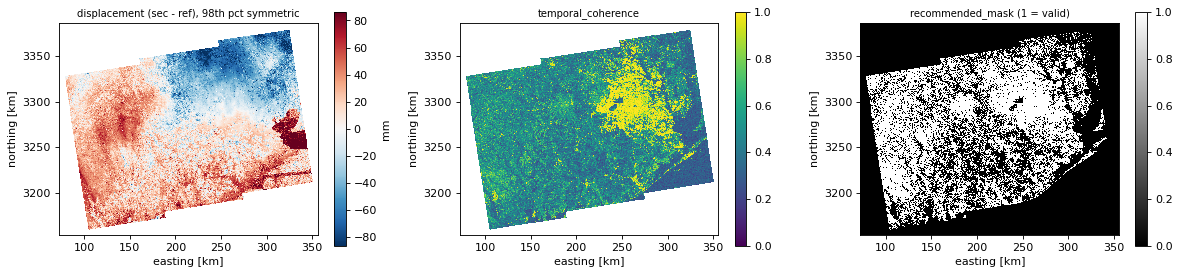

displacement (dec)     shape=(645, 789) dtype=float64 finite= 64.7%  min=-0.142792 max=0.203552 mean=0.0075823 std=0.03758 m
[1 disp product] elapsed since start: 5 s


In [7]:
# Decimated look at the raw displacement and the quality layers (strided reads; the full layer is loaded in stage 6)
disp_dec = ds_disp.displacement[::DEC, ::DEC].values
tcoh_dec = ds_disp.temporal_coherence[::DEC, ::DEC].values
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
show(axes[0], disp_dec, "displacement (sec - ref), 98th pct symmetric", dec=1)
show(axes[1], tcoh_dec, "temporal_coherence", units="", scale=1, cmap="viridis", sym=False, vmin=0, vmax=1, dec=1)
show(axes[2], ds_disp.recommended_mask[::DEC, ::DEC].values, "recommended_mask (1 = valid)", units="", scale=1, cmap="gray", sym=False, vmin=0, vmax=1, dec=1)
plt.tight_layout(); plt.show()
stats("displacement (dec)", disp_dec, "m")
stage_done("1 disp product")

## 2. Input consistency

Right after opening the DISP product, `run_calibration` calls
`cal_disp.prep.consistency.check_input_geometry(disp_product, los_file, dem_file)`: the static layers must be on
the DISP grid (same shape, transform to within 1e-6 pixel, same CRS) and belong to the same frame, otherwise it
raises a `ValueError` naming the file and the values that differ. Without it, same-shape static layers of
another frame would silently misproject the GNSS field to LOS. The cell runs the same check and prints the three
grids side by side. (The TROPO coverage check runs later, inside `prepare_troposphere_correction`.)

In [8]:
from cal_disp.prep.consistency import check_input_geometry

check_input_geometry(disp_product, los_file, dem_file)   # raises ValueError on any mismatch
print("check_input_geometry: LOS and DEM are on the DISP grid and belong to the same frame")

with rasterio.open(los_file) as src:
    print(f"LOS : {src.count} bands {src.height} x {src.width} {src.dtypes[0]} EPSG:{src.crs.to_epsg()} res={src.res} bounds={tuple(round(b) for b in src.bounds)}")
with rasterio.open(dem_file) as src:
    print(f"DEM : {src.count} band  {src.height} x {src.width} {src.dtypes[0]} EPSG:{src.crs.to_epsg()} res={src.res} bounds={tuple(round(b) for b in src.bounds)}")
print(f"DISP:         {len(y)} x {len(x)} EPSG:{disp_product.get_epsg()} res=({x_spacing:g}, {y_spacing:g}) bounds={tuple(round(b) for b in (west, south, east, north))}")

cal_disp.prep.consistency INFO: Input geometry DISP: frame F08882, shape (7733, 9464), EPSG:32615, origin (71970.000, 3385920.000), pixel (30, -30)


cal_disp.prep.consistency INFO: Input geometry LOS: frame F08882, shape (7733, 9464), EPSG:32615, origin (71970.000, 3385920.000), pixel (30, -30)


cal_disp.prep.consistency INFO: Input geometry DEM: frame F08882, shape (7733, 9464), EPSG:32615, origin (71970.000, 3385920.000), pixel (30, -30)


check_input_geometry: LOS and DEM are on the DISP grid and belong to the same frame
LOS : 3 bands 7733 x 9464 float32 EPSG:32615 res=(30.0, 30.0) bounds=(71970, 3153930, 355890, 3385920)
DEM : 1 band  7733 x 9464 float16 EPSG:32615 res=(30.0, 30.0) bounds=(71970, 3153930, 355890, 3385920)
DISP:         7733 x 9464 EPSG:32615 res=(30, 30) bounds=(71970, 3153930, 355890, 3385920)


## 3. GNSS reference

`_setup_gnss_reference` symlinks the staged UNR files (`grid_latlon_lookup.txt` and the
`*_<frame>_<grid_type>.tenv8` station files) into `<work>/gnss`, where Venti's
`GNSSReference.download_stations()` finds them instead of downloading; the frame's UTM bounds
(south, north, west, east) select the grid stations inside the frame.

In [9]:
from cal_disp.workflow import _setup_gnss_reference

gnss_dir = work_directory / "gnss"
gnss_ref = _setup_gnss_reference(
    disp_product=disp_product,
    unr_grid_latlon_file=unr_grid_latlon_file,
    unr_timeseries_dir=unr_timeseries_dir,
    gnss_dir=gnss_dir,
    reference_frame=cal.reference_frame,
    grid_type=cal.grid_type,
)
print("bounds (S, N, W, E):", gnss_ref.bounds, " EPSG:", gnss_ref.utm_epsg, " frame:", gnss_ref.reference_frame, " grid:", gnss_ref.grid_type)
first = gnss_ref.station_files[0]
print("station files      :", len(gnss_ref.station_files), "e.g.", first.name, "->", os.readlink(first) if first.is_symlink() else "(copy)")
print("gnss_dir contents  :", sorted(p.name for p in gnss_dir.iterdir())[:4], "...")
station_gdf = gnss_ref.station_gdf
display(station_gdf.head())

# The rates Venti will interpolate (constant grid: read straight from the .tenv8 files)
velocity_gdf = gnss_ref._build_velocity_gdf()
ok = np.isfinite(velocity_gdf[["deast", "dnorth", "dup"]]).all(axis=1)
print(f"stations with finite ENU rates: {int(ok.sum())} / {len(velocity_gdf)}; venti.gnss.los.project_to_los also drops stations"
      " whose LOS sample is (e, n) = (0, 0), i.e. outside the swath (see its log line in stage 5)")
display(velocity_gdf.describe().loc[["mean", "std", "min", "max"]].round(3))

venti.gnss.reference INFO: Found 106 GNSS stations in bounds


venti.gnss.reference INFO: Downloaded 106 station files


cal_disp.workflow INFO: GNSS setup complete: 106 stations available


bounds (S, N, W, E): (3153945.0, 3385905.0, 71985.0, 355875.0)  EPSG: 32615  frame: IGS20  grid: constant
station files      : 106 e.g. 005970_IGS20_constant.tenv8 -> /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden/input_data/gnss/005970_IGS20_constant.tenv8
gnss_dir contents  : ['005797_IGS20_constant.tenv8', '005798_IGS20_constant.tenv8', '005799_IGS20_constant.tenv8', '005800_IGS20_constant.tenv8'] ...


,lon,lat,geometry
id,,,
5970,262.802461,28.620832,POINT (89476.842 3173189.719)
5971,263.048530,28.620832,POINT (113564.048 3172367.804)
5972,263.294600,28.620832,POINT (137647.468 3171595.803)
5973,263.540670,28.620832,POINT (161727.248 3170873.666)
5974,263.786740,28.620832,POINT (185803.628 3170201.345)


venti.gnss.reference INFO: grid_type='constant': reading precomputed rates directly; start_year=2014.0000 is not applied


stations with finite ENU rates: 106 / 106; venti.gnss.los.project_to_los also drops stations whose LOS sample is (e, n) = (0, 0), i.e. outside the swath (see its log line in stage 5)


,deast,dnorth,dup,dsigma_e,dsigma_n,dsigma_u
mean,-12.173,-2.476,-3.028,0.204,0.192,0.873
std,0.369,0.361,2.168,0.144,0.125,1.330
min,-12.889,-3.243,-14.011,0.010,0.012,0.032
max,-11.558,-1.521,-0.805,0.713,0.521,6.065


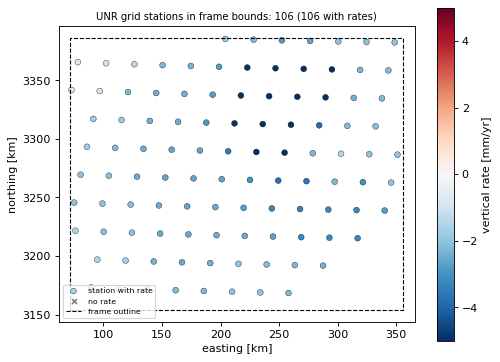

[3 gnss reference] elapsed since start: 7 s


In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(velocity_gdf.geometry.x[ok] / 1e3, velocity_gdf.geometry.y[ok] / 1e3, c=velocity_gdf.dup[ok],
                cmap="RdBu_r", vmin=-5, vmax=5, s=28, edgecolor="k", linewidth=0.3, label="station with rate")
ax.scatter(velocity_gdf.geometry.x[~ok] / 1e3, velocity_gdf.geometry.y[~ok] / 1e3, marker="x", c="gray", s=20, label="no rate")
ax.plot([west/1e3, east/1e3, east/1e3, west/1e3, west/1e3], [south/1e3, south/1e3, north/1e3, north/1e3, south/1e3], "k--", lw=1, label="frame outline")
ax.set_xlim(west / 1e3 - 10, east / 1e3 + 10); ax.set_ylim(south / 1e3 - 10, north / 1e3 + 10)
ax.set_xlabel("easting [km]"); ax.set_ylabel("northing [km]"); ax.set_aspect("equal")
ax.set_title(f"UNR grid stations in frame bounds: {len(velocity_gdf)} ({int(ok.sum())} with rates)", fontsize=9)
plt.colorbar(sc, ax=ax, shrink=0.8, label="vertical rate [mm/yr]"); ax.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()
stage_done("3 gnss reference")

## 4. LOS unit vectors

`_load_los_bands` reads the three bands (east, north, up) of the static LOS GeoTIFF as float32. They project the
GNSS ENU velocities into the radar line of sight (`gnss_los = e·v_e + n·v_n + u·v_u`) and the zenith tropospheric
delay to slant (`/ los_up`).

cal_disp.prep.consistency INFO: LOS: 24789047 of 73185112 pixels without data set to NaN


los_east               shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.708984 max=-0.5 mean=-0.614565 std=0.05994 


los_north              shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.121826 max=-0.0976562 mean=-0.111977 std=0.006816 


los_up                 shape=(7733, 9464) dtype=float32 finite= 66.1%  min=0.694336 max=0.860352 mean=0.777072 std=0.04797 


|los|                  shape=(7733, 9464) dtype=float32 finite= 66.1%  min=0.999312 max=1.00068 mean=1.00001 std=0.0003116 


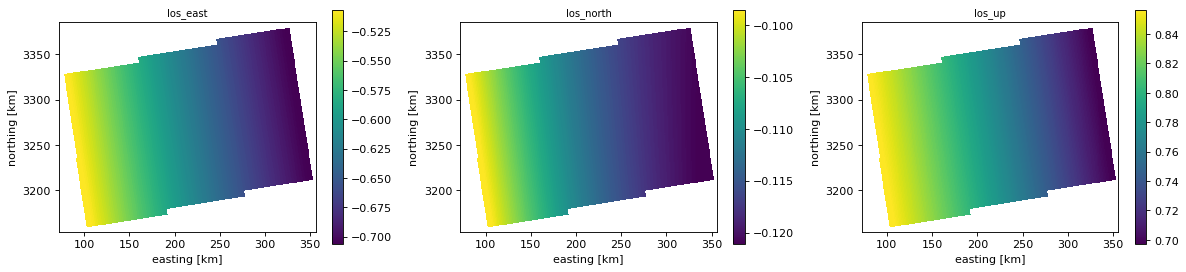

[4 los] elapsed since start: 18 s


In [11]:
from cal_disp.workflow import _load_los_bands

los_east, los_north, los_up = _load_los_bands(los_file)
for name, a in (("los_east", los_east), ("los_north", los_north), ("los_up", los_up)):
    stats(name, a)
norm = np.sqrt(los_east**2 + los_north**2 + los_up**2)
stats("|los|", norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, a, n in zip(axes, (los_east, los_north, los_up), ("east", "north", "up")):
    show(ax, a, f"los_{n}", units="", scale=1, cmap="viridis", sym=False)
plt.tight_layout(); plt.show()
del norm
stage_done("4 los")

## 5. GNSS LOS field

`_gnss_los_fields` calls `venti.gnss.compute_gnss_los` / `compute_gnss_los_std` (RBF interpolation of the
station LOS rates, times the interval `sec - ref` in decimal years, in mm). With `downsample_factor > 1` both
fields are evaluated only at the **block centres** of the fit grid (`x[c::f]`, `y[c::f]`, `c = f // 2`) and
bilinearly interpolated back to the full grid with `_upsample_centres` (edge values held beyond the outermost
centres); the fit only ever sees block means, so this changes the result by ≤ 0.01 mm while turning ~90 min of
RBF evaluation into seconds. Venti caches the velocity fields as `.npy` in `<work>/gnss`.
Everything is converted from mm to m.

In [12]:
from cal_disp.workflow import _date_to_decimal_year, _gnss_los_fields, _upsample_centres

ref_decimal = _date_to_decimal_year(disp_product.reference_date)
sec_decimal = _date_to_decimal_year(disp_product.secondary_date)
print(f"epochs: ref={ref_decimal:.4f}  sec={sec_decimal:.4f}  interval={sec_decimal - ref_decimal:.4f} yr")

t = time.perf_counter()
gnss_los, gnss_los_std = _gnss_los_fields(
    gnss_ref,
    (los_east, los_north, los_up),
    disp_file,
    x, y,
    cal.downsample_factor,
    gnss_dir,
    ref_decimal,
    sec_decimal,
)
print(f"_gnss_los_fields: {time.perf_counter() - t:.1f} s")
stats("gnss_los", gnss_los, "m")
stats("gnss_los_std", gnss_los_std, "m")
neg = gnss_los_std < 0
print(f"gnss_los_std < 0 (RBF overshoot): {int(neg.sum()):,} px ({neg.mean():.3%}), min {gnss_los_std.min()*1e3:.3f} mm"
      " -> clipped to 0 in calibration_std (stage 10); passed unclipped to the fit only if weight_fit_by_gnss_uncertainty")

# The block-centre grid Venti actually evaluated, from its cache
c = cal.downsample_factor // 2
xc, yc = x[c::cal.downsample_factor], y[c::cal.downsample_factor]
vel_centres = np.load(gnss_dir / "gnss_los_velocity.npy")     # mm/yr at block centres
print(f"block-centre grid: {len(yc)} x {len(xc)} (factor {cal.downsample_factor}); cached velocity {vel_centres.shape} {vel_centres.dtype}")
# _upsample_centres applied to the cached velocity reproduces gnss_los (up to float32 rounding of the scaling)
check = _upsample_centres(vel_centres * (sec_decimal - ref_decimal), xc, yc, x, y).astype(np.float32) / 1000.0
print("max |upsampled(cached velocity * interval) - gnss_los| =", f"{np.nanmax(np.abs(check - gnss_los))*1e3:.2e} mm")
del check

epochs: ref=2022.0274  sec=2022.5535  interval=0.5260 yr
venti.gnss.reference INFO: grid_type='constant': reading precomputed rates directly; start_year=2014.0000 is not applied


venti.gnss.los INFO: Interpolating LOS from 74 GNSS stations using method='rbf'


venti.gnss.reference INFO: Saved GNSS LOS velocity to /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work/gnss/gnss_los_velocity.npy


venti.gnss.reference INFO: grid_type='constant': reading precomputed rates directly; start_year=2014.0000 is not applied


venti.gnss.los INFO: Interpolating LOS uncertainty from 74 GNSS stations using method='rbf'


venti.gnss.reference INFO: Saved GNSS LOS velocity uncertainty to /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/notebook/_work/gnss/gnss_los_velocity_std.npy


_gnss_los_fields: 24.4 s


gnss_los               shape=(7733, 9464) dtype=float32 finite=100.0%  min=-0.00140691 max=0.00555337 mean=0.00290235 std=0.0008686 m


gnss_los_std           shape=(7733, 9464) dtype=float32 finite=100.0%  min=-0.00139806 max=0.00300094 mean=0.000394255 std=0.0006015 m
gnss_los_std < 0 (RBF overshoot): 3,867,584 px (5.285%), min -1.398 mm -> clipped to 0 in calibration_std (stage 10); passed unclipped to the fit only if weight_fit_by_gnss_uncertainty
block-centre grid: 1289 x 1577 (factor 6); cached velocity (1289, 1577) float32


max |upsampled(cached velocity * interval) - gnss_los| = 0.00e+00 mm


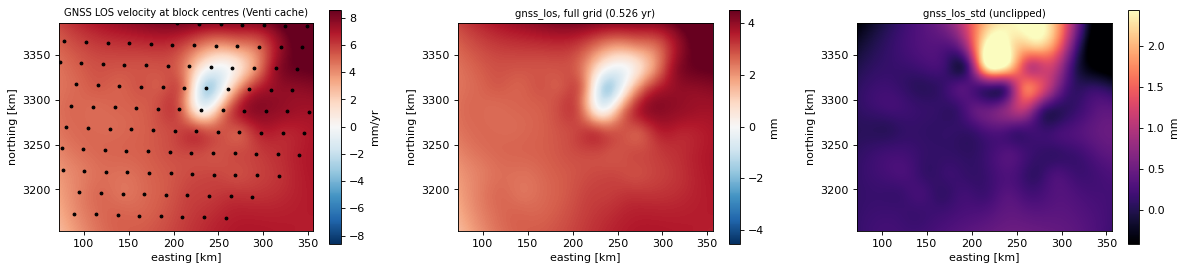

[5 gnss los] elapsed since start: 49 s


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
show(axes[0], vel_centres, "GNSS LOS velocity at block centres (Venti cache)", units="mm/yr", scale=1, dec=1)
axes[0].scatter(velocity_gdf.geometry.x[ok] / 1e3, velocity_gdf.geometry.y[ok] / 1e3, s=6, c="k")
show(axes[1], gnss_los, f"gnss_los, full grid ({sec_decimal - ref_decimal:.3f} yr)")
show(axes[2], gnss_los_std, "gnss_los_std (unclipped)", cmap="magma", sym=False, vmin=0)
plt.tight_layout(); plt.show()
stage_done("5 gnss los")

## 6. Displacement and masks

`_load_displacement` reads the float64 `displacement` in row blocks straight into a float32 array (the values
equal `displacement.values.astype(np.float32)`; the float64 array is never held or cached in `ds_disp`). The
valid mask is `~isnan(disp) & recommended_mask & water_mask`. An event mask (True = valid; masked areas are
*filled from neighbours* before the fit rather than dropped) is built by `_build_event_mask` from the GeoJSON
databases only when the runconfig names them. With `downsample_weighted`, `temporal_coherence` becomes the
downsampling weight.

_load_displacement: 2.4 s


disp_2d                shape=(7733, 9464) dtype=float32 finite= 64.8%  min=-0.161926 max=0.237762 mean=0.00756929 std=0.03756 m
displacement still lazy in ds_disp: True
finite displacement : 64.82%


& recommended_mask  : 36.41%  (recommended_mask alone: 36.41%)


& water_mask        : 36.41%  (water_mask alone: 81.91%)
valid pixels for the fit: 26,643,627 / 73,185,112 (36.41%)
no deformation-area / event database in the runconfig -> event_mask = None
downsample_weighted = False -> unweighted block means


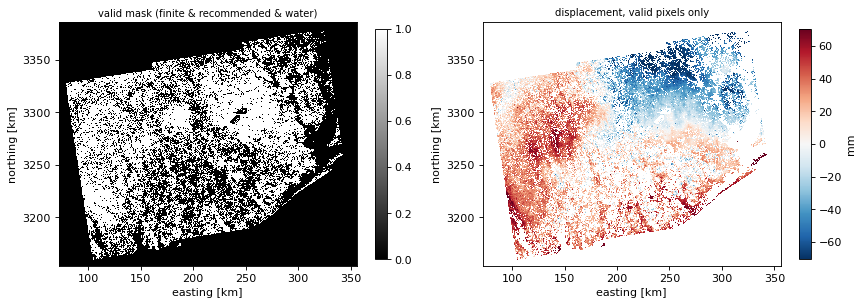

[6 displacement + masks] elapsed since start: 55 s


In [14]:
from cal_disp.workflow import _build_event_mask, _load_displacement

t = time.perf_counter()
disp_2d = _load_displacement(ds_disp)
print(f"_load_displacement: {time.perf_counter() - t:.1f} s")
stats("disp_2d", disp_2d, "m")
print("displacement still lazy in ds_disp:", not ds_disp["displacement"].variable._in_memory)

mask = ~np.isnan(disp_2d)
print(f"finite displacement : {mask.mean():.2%}")
if "recommended_mask" in ds_disp:
    rec = ds_disp.recommended_mask.values.astype(bool)
    mask &= rec
    print(f"& recommended_mask  : {mask.mean():.2%}  (recommended_mask alone: {rec.mean():.2%})")
    del rec
if "water_mask" in ds_disp:
    wat = ds_disp.water_mask.values.astype(bool)
    mask &= wat
    print(f"& water_mask        : {mask.mean():.2%}  (water_mask alone: {wat.mean():.2%})")
    del wat
print(f"valid pixels for the fit: {int(mask.sum()):,} / {mask.size:,} ({mask.mean():.2%})")

event_mask = None
if defo_area_db_json is not None or event_db_json is not None:
    event_mask_file = _build_event_mask(disp_file=disp_file, defo_area_db=defo_area_db_json,
                                        event_db=event_db_json, mask_dir=work_directory / "event_masks")
    if event_mask_file is not None:
        with rasterio.open(event_mask_file) as _src:
            event_mask = _src.read(1).astype(bool)
        print("event mask:", event_mask_file, f"{int((~event_mask).sum()):,} pixels to fill")
else:
    print("no deformation-area / event database in the runconfig -> event_mask = None")

weights = None
if cal.downsample_factor > 1 and cal.downsample_weighted:
    weights = ds_disp.temporal_coherence.values.astype(np.float32)
    stats("downsample weights", weights)
else:
    print("downsample_weighted = False -> unweighted block means")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
show(axes[0], mask.astype(np.float32), "valid mask (finite & recommended & water)", units="", scale=1, cmap="gray", sym=False, vmin=0, vmax=1)
show(axes[1], np.where(mask, disp_2d, np.nan), "displacement, valid pixels only")
plt.tight_layout(); plt.show()
stage_done("6 displacement + masks")

## 7. Corrections: troposphere and solid Earth tide

Signals the GNSS reference does **not** contain are removed from the displacement before the fit and added back
to the surface afterwards (`surface = fit(disp - c, gnss) + c`; the fit is near-linear, so leaving a smooth
correction in would let the plane absorb part of it). The sign convention is therefore: a correction `c` enters
`estimate_calibration_surface` as something to *subtract* from `disp`, and it returns in the surface with a
*plus* sign, so `disp - surface` is free of it.

* **Troposphere** — `prep/tropo.prepare_troposphere_correction` interpolates the OPERA TROPO-ZENITH total delay to
  the DEM surface for each date, projects zenith → slant (`/ los_up`) and writes one GeoTIFF per date. The
  correction is the *differential* delay `sec - ref` (same order as the displacement).
* **Solid Earth tide** — `/corrections/solid_earth_tide` from the DISP product itself (`venti.io.read_netcdf_correction`);
  UNR positions already have it removed.

In [15]:
from cal_disp.prep.tropo import prepare_troposphere_correction
from venti.io import read_netcdf_correction

corrections = []
_tropo_applied = False
use_tropo = bool(reference_tropo_files and secondary_tropo_files)
if use_tropo and not cal.apply_tropo_correction:
    print("apply_tropo_correction=false; ignoring the tropo files")
    use_tropo = False
if use_tropo:
    if dem_file is None:
        raise ValueError("dem_file is required when tropospheric correction files are provided")
    tropo_dir = work_directory / "troposphere"
    t = time.perf_counter()
    ref_tropo_path, sec_tropo_path = prepare_troposphere_correction(
        disp_file=disp_file,
        dem_file=dem_file,
        los_file=los_file,
        reference_tropo_files=reference_tropo_files,
        secondary_tropo_files=secondary_tropo_files,
        output_dir=tropo_dir,
    )
    print(f"prepare_troposphere_correction: {time.perf_counter() - t:.1f} s -> {ref_tropo_path.name}, {sec_tropo_path.name}")
    with rasterio.open(ref_tropo_path) as _src:
        ref_tropo = _src.read(1).astype(np.float32)
        print("tropo GeoTIFF:", _src.dtypes[0], _src.shape, "EPSG:" + str(_src.crs.to_epsg()), _src.res)
    with rasterio.open(sec_tropo_path) as _src:
        sec_tropo = _src.read(1).astype(np.float32)
    corrections.append(sec_tropo - ref_tropo)
    _tropo_applied = True
    stats("ref tropo (slant)", ref_tropo, "m")
    stats("sec tropo (slant)", sec_tropo, "m")
    stats("sec - ref", corrections[-1], "m")
else:
    print("no tropospheric correction")

_set_applied = False
if cal.apply_solid_earth_tide_correction:
    set_corr = read_netcdf_correction(disp_file, "solid_earth_tide")
    if set_corr is None:
        print(f"No /corrections/solid_earth_tide in {disp_file.name}; calibrating without SET correction")
    else:
        print("solid_earth_tide on disk:", set_corr.dtype, set_corr.shape)
        corrections.append(set_corr.astype(np.float32))
        _set_applied = True
        stats("solid_earth_tide", corrections[-1], "m")
        del set_corr
print("corrections applied:", [n for n, a in (("troposphere", _tropo_applied), ("solid_earth_tide", _set_applied)) if a])

total_correction = np.zeros(disp_2d.shape, dtype=np.float32)
for c_ in corrections:
    total_correction += c_
stats("total correction", total_correction, "m")

prepare_troposphere_correction: 118.0 s -> 20220111.tif, 20220722.tif


tropo GeoTIFF: float32 (7733, 9464) EPSG:32615 (30.0, 30.0)


ref tropo (slant)      shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-3.47529 max=-2.73819 mean=-3.08525 std=0.1942 m
sec tropo (slant)      shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-3.73296 max=-2.83521 mean=-3.23682 std=0.2472 m


sec - ref              shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.311925 max=-0.0707364 mean=-0.15157 std=0.06195 m


solid_earth_tide on disk: float32 (7733, 9464)


solid_earth_tide       shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.0121613 max=0.00654602 mean=-0.00268058 std=0.005038 m
corrections applied: ['troposphere', 'solid_earth_tide']


total correction       shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.306463 max=-0.0776954 mean=-0.15425 std=0.05789 m


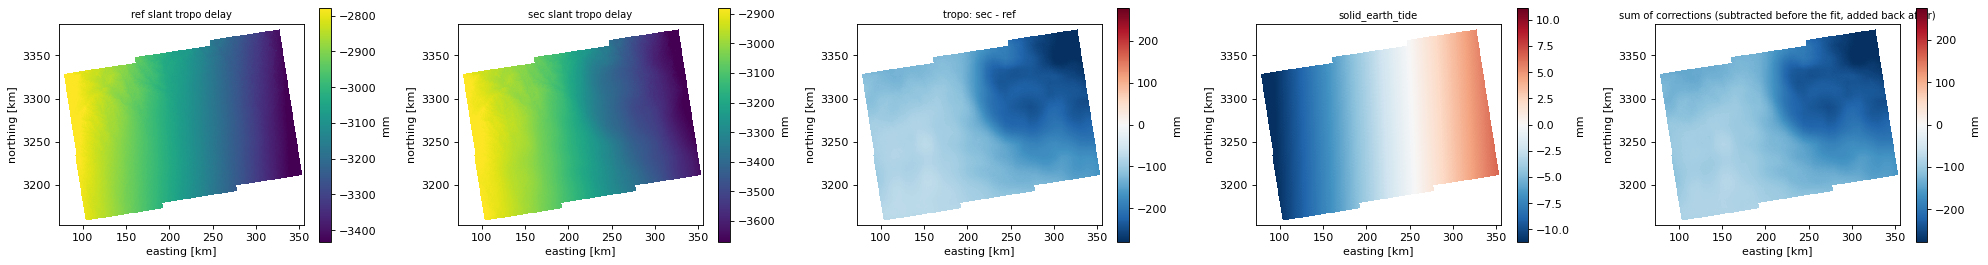

[7 corrections] elapsed since start: 179 s


In [16]:
panels = []
if _tropo_applied:
    panels += [(ref_tropo, "ref slant tropo delay"), (sec_tropo, "sec slant tropo delay"), (sec_tropo - ref_tropo, "tropo: sec - ref")]
if _set_applied:
    panels += [(corrections[-1], "solid_earth_tide")]
panels += [(total_correction, "sum of corrections (subtracted before the fit, added back after)")]
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.2))
for ax, (a, title) in zip(np.atleast_1d(axes), panels):
    sym = not title.endswith("delay")
    show(ax, a, title, sym=sym, cmap="RdBu_r" if sym else "viridis")
plt.tight_layout(); plt.show()
stage_done("7 corrections")

## 8. Reference point

InSAR has no absolute datum, so the displacement is zeroed at one pixel before the fit and the offset is added
back to the surface. `_find_reference_point` writes the product's `temporal_coherence` (0 outside the valid mask)
to a GeoTIFF and applies `opera_utils.disp.rebase_reference.find_reference_point`; if nothing passes its
quality threshold the best pixel is taken.

cal_disp.workflow INFO: Reference pixel (row, col): (3051, 6254)


ref_point (row, col)     : (3051, 6254)  -> UTM (259605.0, 3294375.0)
displacement there       : -14.223 mm  (must be finite)
temporal coherence there : 0.9921875
DISP product's own ref   : (2942, 5993) (informational; not used)


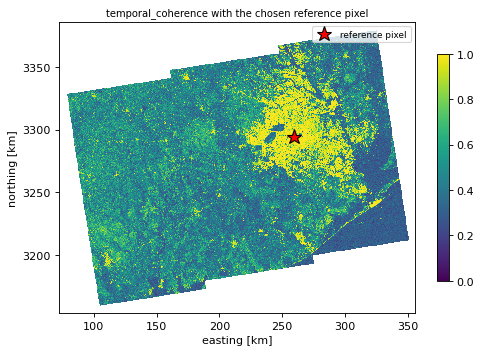

[8 reference point] elapsed since start: 182 s


In [17]:
from cal_disp.workflow import _find_reference_point

ref_point = _find_reference_point(ds_disp, mask, work_directory)
r0, c0 = ref_point
print("ref_point (row, col)     :", ref_point, " -> UTM", (float(x[c0]), float(y[r0])))
print("displacement there       :", f"{disp_2d[r0, c0]*1e3:.3f} mm  (must be finite)")
print("temporal coherence there :", float(ds_disp.temporal_coherence[r0, c0].values))
print("DISP product's own ref   :", disp_product.get_reference_point_index(), "(informational; not used)")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
show(ax, tcoh_dec, "temporal_coherence with the chosen reference pixel", units="", scale=1, cmap="viridis", sym=False, vmin=0, vmax=1, dec=1)
ax.plot(x[c0] / 1e3, y[r0] / 1e3, "r*", ms=14, mec="k", label="reference pixel")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
stage_done("8 reference point")

## 9. Calibration surface

`venti.surface.estimate_calibration_surface` does, in order: subtract the corrections, zero at the reference pixel,
apply the mask, (optionally) the region-offset **unwrap-error correction** with cycle `wavelength_m`, fill event
regions, **downsample** by `downsample_factor` (block `mean`), fit Hann-tapered **windowed planes**
(`poly_order=1.5`, 50 % overlap) to `disp - gnss_los`, smooth, upsample, and add the corrections and reference
offset back.

`run_calibration` passes the *unwrap cycle length* λ/2 (`_unwrap_cycle_length_m`) as `wavelength_m`: Venti rounds
region offsets to integer multiples of that value, and one 2π cycle is λ/2 of two-way LOS displacement. The
wavelength is read from the product when `unwrap_error_correction` is on (so NISAR gets its own λ), otherwise
Venti's Sentinel-1 constant is used (the value is then irrelevant). The `unwrap_error_correction` flag itself
comes from the algorithm parameters, as loaded in stage 0.

In [18]:
from venti.surface import SENTINEL1_WAVELENGTH_M, estimate_calibration_surface

wavelength_m = _read_wavelength_m(disp_file) if cal.unwrap_error_correction else SENTINEL1_WAVELENGTH_M
unwrap_cycle_m = _unwrap_cycle_length_m(wavelength_m)
print(f"unwrap_error_correction={cal.unwrap_error_correction}: wavelength_m={wavelength_m:.6f} m -> "
      f"cycle passed to Venti = {unwrap_cycle_m*1e3:.3f} mm")
print(f"window: {cal.window_size_pixels} px full-res -> {max(1, cal.window_size_pixels // cal.downsample_factor)} px on the "
      f"{len(yc)} x {len(xc)} downsampled grid; n_jobs={threads_per_worker}")

t = time.perf_counter()
result = estimate_calibration_surface(
    disp_2d,
    gnss_los,
    mask,
    ref_point,
    cal.window_size_pixels,
    corrections=corrections,
    gnss_los_std=gnss_los_std if cal.weight_fit_by_gnss_uncertainty else None,
    event_mask=event_mask,
    options=cal.to_venti(),
    wavelength_m=unwrap_cycle_m,
    downsample_factor=cal.downsample_factor,
    downsample_method=cal.downsample_method,
    downsample_weights=weights,
    n_jobs=threads_per_worker,
)
print(f"estimate_calibration_surface: {time.perf_counter() - t:.1f} s")
print("result:", type(result).__name__, "n_auto_masked_pixels =", result.n_auto_masked_pixels,
      " n_region_masked_pixels =", result.n_region_masked_pixels)
cal_surface_m = result.surface.astype(np.float32)
nodata_pixel_count = int(np.isnan(cal_surface_m).sum())
stats("surface", cal_surface_m, "m")
print(f"nodata_pixel_count = {nodata_pixel_count:,}  ({nodata_pixel_count / cal_surface_m.size:.2%})")
print(f"surface - total_correction - disp0 at the reference pixel: "
      f"{(cal_surface_m[r0, c0] - total_correction[r0, c0] - disp_2d[r0, c0])*1e3:.4f} mm (the fitted plane there)")

unwrap_error_correction=False: wavelength_m=0.055460 m -> cycle passed to Venti = 27.730 mm
window: 20000 px full-res -> 3333 px on the 1289 x 1577 downsampled grid; n_jobs=1


venti.surface INFO: Downsampling by factor 6 using 'mean'


venti.filtering.moving_window INFO: Fitting windowed calibration plane: 3333 x 3333 px windows, poly_order=1.5


venti.filtering.moving_window INFO: Processing 1 windows (n_jobs=1)


estimate_calibration_surface: 5.9 s
result: CalibrationSurface n_auto_masked_pixels = None  n_region_masked_pixels = None


surface                shape=(7733, 9464) dtype=float32 finite= 66.1%  min=-0.0967718 max=0.144996 mean=0.0181327 std=0.049 m
nodata_pixel_count = 24,789,047  (33.87%)
surface - total_correction - disp0 at the reference pixel: 189.6489 mm (the fitted plane there)


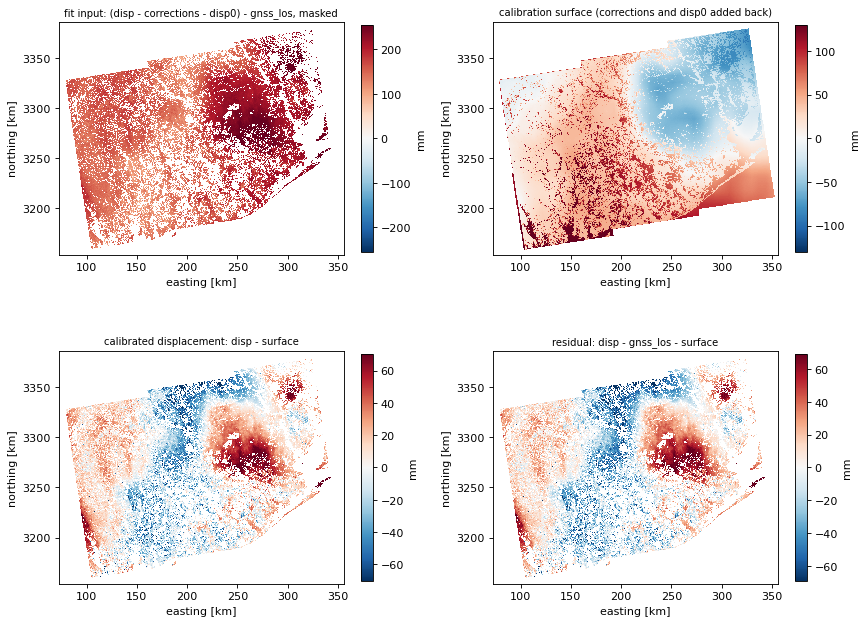

residual (valid px): n=26,643,627 median=4.901 mm  robust sigma=27.761 mm  RMS=30.325 mm  [p1, p99]=(-72.43, 68.04) mm


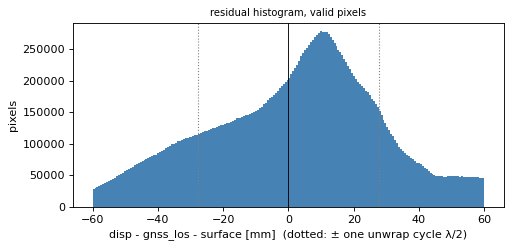

[9 calibration surface] elapsed since start: 190 s


In [19]:
# What the fit saw (before downsampling): corrected, reference-zeroed, masked displacement minus GNSS
fit_input = np.where(mask, disp_2d - total_correction - disp_2d[r0, c0], np.nan) - gnss_los
# Residual after calibration: calibrated displacement (disp - surface) minus the GNSS reference
residual = np.where(mask, disp_2d - gnss_los - cal_surface_m, np.nan)
calibrated = disp_2d - cal_surface_m

fig, axes = plt.subplots(2, 2, figsize=(11, 8.4))
show(axes[0, 0], fit_input, "fit input: (disp - corrections - disp0) - gnss_los, masked")
show(axes[0, 1], cal_surface_m, "calibration surface (corrections and disp0 added back)")
show(axes[1, 0], np.where(mask, calibrated, np.nan), "calibrated displacement: disp - surface")
show(axes[1, 1], residual, "residual: disp - gnss_los - surface")
plt.tight_layout(); plt.show()

r = residual[np.isfinite(residual)] * 1e3
med, mad = np.median(r), 1.4826 * np.median(np.abs(r - np.median(r)))
print(f"residual (valid px): n={r.size:,} median={med:.3f} mm  robust sigma={mad:.3f} mm  RMS={np.sqrt(np.mean(r**2)):.3f} mm  "
      f"[p1, p99]=({np.percentile(r, 1):.2f}, {np.percentile(r, 99):.2f}) mm")
if cal.unwrap_error_correction:
    print("NOTE: unwrap_error_correction is on, so the fit saw a region-shifted field, not `disp`;"
          " the residual against raw `disp` contains those n x lambda/2 shifts (next cell).")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(r, bins=200, range=(-60, 60), color="steelblue")
for k in (-1, 1):
    ax.axvline(k * unwrap_cycle_m * 1e3, color="gray", ls=":", lw=1)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("disp - gnss_los - surface [mm]  (dotted: ± one unwrap cycle λ/2)"); ax.set_ylabel("pixels")
ax.set_title("residual histogram, valid pixels", fontsize=9)
plt.tight_layout(); plt.show()
del fit_input, calibrated, r

if cal.unwrap_error_correction:
    # The fit did not see `disp` but Venti's unwrap-corrected field: every mask region shifted by an
    # integer number of cycles (see notebook 01 for why this is off by default). Reproduce that field
    # with the same call as estimate_calibration_surface and show the residual against it.
    from venti.unwrap import correct_region_offset

    zeroed = np.where(mask, disp_2d - total_correction - disp_2d[r0, c0], np.nan).astype(np.float32)
    t = time.perf_counter()
    disp_uw = np.ma.filled(correct_region_offset(input_disp=zeroed, mask=mask, wavelength=unwrap_cycle_m), np.nan)
    print(f"correct_region_offset: {time.perf_counter() - t:.1f} s")
    shifts = (disp_uw - zeroed) / unwrap_cycle_m
    residual_uw = disp_uw - gnss_los - (cal_surface_m - total_correction - disp_2d[r0, c0])
    r = residual_uw[np.isfinite(residual_uw)] * 1e3
    s_ = shifts[np.isfinite(shifts)]
    print(f"region shifts applied before the fit: {np.mean(np.abs(s_) > 0.5):.1%} of valid pixels, "
          f"range {s_.min():+.0f} .. {s_.max():+.0f} cycles of {unwrap_cycle_m*1e3:.1f} mm")
    print(f"residual vs the unwrap-corrected field: median={np.median(r):.3f} mm  robust sigma="
          f"{1.4826 * np.median(np.abs(r - np.median(r))):.3f} mm  RMS={np.sqrt(np.mean(r**2)):.3f} mm")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    show(axes[0], shifts, "cycles added by the unwrap correction (per region)", units="cycles", scale=1,
         cmap="RdBu_r", vmin=-max(1, np.nanpercentile(np.abs(shifts[::DEC, ::DEC]), 99)), vmax=max(1, np.nanpercentile(np.abs(shifts[::DEC, ::DEC]), 99)))
    show(axes[1], residual_uw, "residual: unwrap-corrected disp - gnss_los - fit")
    plt.tight_layout(); plt.show()
    del zeroed, disp_uw, shifts, residual_uw, r, s_
stage_done("9 calibration surface")

## 10. Product assembly

`run_calibration` wraps the surface and the GNSS uncertainty (clipped at 0) into `(time, y, x)` DataArrays, adds a
zero 3-D velocity placeholder on a 167-pixel (≈ 5 km) grid, and writes the product with `CalProduct.create`
(main group) + `add_identification` + `add_metadata` + `add_auxiliary`, with the argument lists below copied
from `run_calibration`. The filename carries the production time, so it differs from run to run. `main.run` then
writes the browse PNG with `make_browse_image_from_nc`.

In [20]:
import importlib.metadata

coords = {"time": time_coord, "y": y, "x": x}
calibration = xr.DataArray(
    cal_surface_m[np.newaxis, :, :],
    coords=coords,
    dims=["time", "y", "x"],
    attrs={
        "units": "meters",
        "long_name": "calibration_correction",
        "corrections_applied": (
            ", ".join(name for name, applied in [("troposphere", _tropo_applied), ("solid_earth_tide", _set_applied)] if applied)
            or "none"
        ),
    },
)
calibration_std = xr.DataArray(
    np.clip(gnss_los_std, 0, None)[np.newaxis, :, :],
    coords=coords,
    dims=["time", "y", "x"],
    attrs={
        "units": "meters",
        "long_name": "calibration_uncertainty",
        "uncertainty_source": (
            "GNSS reference uncertainty: UNR"
            f" {cal.grid_type}-grid sigmas projected to LOS and interpolated"
            " to each pixel (rate sigma x interval for 'constant', combined"
            " reference/secondary position sigma for 'variable'). Not the"
            " uncertainty of the fitted calibration surface."
        ),
    },
)

coarse_y = y[::167]
coarse_x = x[::167]
coarse_shape = (len(time_coord), len(coarse_y), len(coarse_x))
coarse_coords = {"time": time_coord, "y": coarse_y, "x": coarse_x}
def _zero_da(long_name, units):
    return xr.DataArray(np.zeros(coarse_shape, dtype=np.float32), coords=coarse_coords, dims=["time", "y", "x"],
                        attrs={"units": units, "long_name": long_name})
model_3d = {
    "north_south": _zero_da("north_south_velocity", "meters/year"),
    "east_west": _zero_da("east_west_velocity", "meters/year"),
    "up_down": _zero_da("up_down_velocity", "meters/year"),
}

def _pkg_version(name):
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return "unknown"
cal_disp_version = _pkg_version("cal-disp")
venti_version = _pkg_version("venti")

print("calibration      :", calibration.dims, calibration.shape, calibration.dtype, calibration.attrs)
print("calibration_std  :", calibration_std.dims, calibration_std.dtype, f"min={float(calibration_std.min()):.3e} (clipped at 0)")
print("model_3d (coarse):", coarse_shape, "spacing", f"{167 * x_spacing / 1e3:.3f} km")
print("versions         : cal-disp", cal_disp_version, "| venti", venti_version, "| DISP", disp_product.version)
if cal_disp_version != cal_disp_pkg_version:
    print(f"NOTE: importlib.metadata reports the installed distribution ({cal_disp_version}); this checkout's"
          f" _version.py says {cal_disp_pkg_version}. The product carries the former, as run_calibration does.")

calibration      : ('time', 'y', 'x') (1, 7733, 9464) float32 {'units': 'meters', 'long_name': 'calibration_correction', 'corrections_applied': 'troposphere, solid_earth_tide'}
calibration_std  : ('time', 'y', 'x') float32 min=0.000e+00 (clipped at 0)
model_3d (coarse): (1, 47, 57) spacing 5.010 km
versions         : cal-disp 0.2.post1.dev62+g4117f9341.d20260930 | venti 0.0.post1.dev80+g2a7e61f0c | DISP 1.0


In [21]:
t = time.perf_counter()
cal_product = CalProduct.create(
    calibration=calibration,
    disp_product=disp_product,
    output_dir=output_dir,
    calibration_std=calibration_std,
    spatial_ref=spatial_ref,
    global_metadata={
        "gnss_reference_epoch": f"{ref_decimal:.4f}",
        "auxiliary_model_3d_resolution": "5km",
        "calibration_resolution": f"{int(x_spacing)}m",
    },
    version=product_version,
    compression=compression,
)

cal_product.add_identification(
    calibration_reference_name=calibration_reference_name,
    calibration_reference_version=calibration_reference_version,
    calibration_reference_type=calibration_reference_type,
    calibration_reference_reference_frame=calibration_reference_reference_frame,
    source_data_file_list=source_data_file_list,
    source_calibration_file_list=source_calibration_file_list,
    source_data_access=source_data_access,
    source_data_dem_name=str(_meta("source_data_dem_name", "unknown")),
    source_data_satellite_names=source_data_satellite_names,
    source_data_imaging_geometry=str(_meta("source_data_imaging_geometry", "unknown")),
    source_data_x_spacing=x_spacing,
    source_data_y_spacing=y_spacing,
    static_layers_data_access=static_layers_data_access,
    absolute_orbit_number=int(_meta("absolute_orbit_number", -1)),
    track_number=int(_meta("track_number", -1)),
    instrument_name=str(_meta("instrument_name", "unknown")),
    look_direction=str(_meta("look_direction", "unknown")).lower(),
    radar_band=str(_meta("radar_band", "unknown")),
    orbit_pass_direction=str(_meta("orbit_pass_direction", "unknown")).lower(),
    bounding_polygon=bounding_polygon,
    product_bounding_box=product_bounding_box,
    product_sample_spacing=product_sample_spacing,
    product_data_access=product_data_access,
    processing_facility=processing_facility,
    nodata_pixel_count=nodata_pixel_count,
    ceos_number_of_input_granules=len(source_data_file_list),
    processing_start_datetime=processing_start,
    ceos_analysis_ready_data_document_identifier=disp_meta.get("ceos_analysis_ready_data_document_identifier"),
    ceos_analysis_ready_data_product_type=disp_meta.get("ceos_analysis_ready_data_product_type"),
)

cal_product.add_metadata(
    algorithm_parameters_yaml=algorithm_parameters_yaml,
    platform_id=platform_id,
    source_data_software_disp_version=disp_product.version,
    cal_disp_software_version=cal_disp_version,
    venti_software_version=venti_version,
    product_pixel_coordinate_convention="center",
    ceos_atmospheric_phase_correction="tropospheric" if _tropo_applied else "none",
    ceos_gridding_convention="consistent",
    ceos_product_measurement_projection="line_of_sight",
    ceos_ionospheric_phase_correction="none",
    ceos_noise_removal="N",
    pge_runconfig=pge_runconfig,
)

cal_product.add_auxiliary(model_3d=model_3d, spatial_ref=spatial_ref)
nb_product = cal_product.path
print(f"CalProduct written in {time.perf_counter() - t:.1f} s: {nb_product.name} ({nb_product.stat().st_size / 1e6:.1f} MB)")

# End of run_calibration: leave the scratch temp dir (deletes <work>/tmp/run_*)
_scratch_stack.close()

CalProduct written in 9.7 s: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.nc (208.6 MB)


browse image OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.png: 1.94 MB, colour limits (-131.42, 131.42) mm, 3.5 s
groups: ['identification', 'metadata', 'auxiliary']
  /calibration      (1, 7733, 9464) float32 chunks=(1, 256, 256) compression=gzip(4) shuffle=True
      attrs: {'DIMENSION_LIST': array([array([<HDF5 object reference>], dtype=object),
       array([<HDF5 object reference>], dtype=object),
       array([<HDF5 object reference>], dtype=object)], dtype=object), '_Netcdf4Coordinates': array([0, 1, 2], dtype=int32), '_Netcdf4Dimid': np.int32(0), '_FillValue': array([nan], dtype=float32), 'units': 'meters', 'long_name': 'Calibration for DISP', 'corrections_applied': 'troposphere, solid_earth_tide', 'description': 'Calibration layer for DISP displacement', 'grid_mapping': 'spatial_ref'}
  /calibration_std  (1, 7733, 9464) float32 chunks=(1, 256, 256) compression=gzip(4) shuffle=True
      attrs: {'DIMENSION_LIST': array([array([<HDF5 

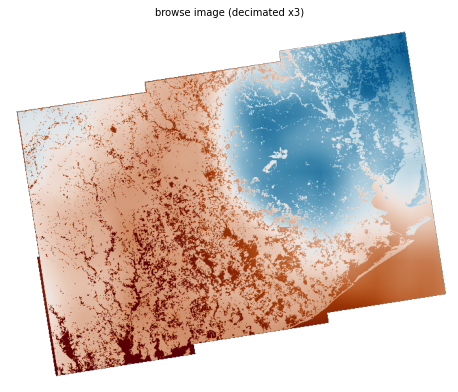

[10 product] elapsed since start: 204 s


In [22]:
from cal_disp.browse_image import make_browse_image_from_nc

t = time.perf_counter()
nb_png = nb_product.with_suffix(".png")
vlim = make_browse_image_from_nc(nb_png, nb_product)
print(f"browse image {nb_png.name}: {nb_png.stat().st_size / 1e6:.2f} MB, colour limits {tuple(round(v * 1e3, 2) for v in vlim)} mm, {time.perf_counter() - t:.1f} s")

import h5py
with h5py.File(nb_product) as f:
    print("groups:", [k for k in f if isinstance(f[k], h5py.Group)])
    for v in ("calibration", "calibration_std"):
        d = f[v]
        print(f"  /{v:<16s} {d.shape} {d.dtype} chunks={d.chunks} compression={d.compression}({d.compression_opts}) shuffle={d.shuffle}")
        print(f"      attrs: {dict(d.attrs)}")
    print("  global attrs:", {k: (v if len(str(v)) < 60 else str(v)[:57] + "...") for k, v in f.attrs.items()})
    ident = f["identification"]
    print("  identification:")
    for k in sorted(ident):
        val = ident[k][()]
        val = val.decode() if isinstance(val, bytes) else val
        print(f"    {k:<48s} {str(val)[:70]}")

png = plt.imread(nb_png)[::3, ::3]
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.imshow(png); ax.set_axis_off(); ax.set_title("browse image (decimated x3)", fontsize=9)
plt.tight_layout(); plt.show()
stage_done("10 product")

## 11. Final tests

### 11a. Notebook product vs the golden product

`cal_disp.validate.compare_cal_products` is what `cal-disp validate` runs: identification metadata, structure,
coordinates, NaN patterns and values of every variable of the main and auxiliary groups, `np.allclose` with
`rtol = atol = tolerance` (CLI default `1e-6`; zeros in the reference are skipped). It compares against whatever
`golden_output/*.nc` contains **at run time**. A FAIL here with a PASS in 11b means the golden product was built
by different code or settings (e.g. an older `algorithm_parameters.yaml`) and needs regenerating — not that the
notebook diverges from the workflow. With no product in `golden_output/` (e.g. while it is being regenerated) 11a is
skipped and reported as such.

In [23]:
from cal_disp.validate import compare_cal_products

TOL = 1e-6   # cal-disp validate default
golden_files = sorted((GOLDEN / "golden_output").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
golden_product = golden_files[0] if golden_files else None
print("notebook:", nb_product.name)
if golden_product is None:
    golden_pass = None
    print(f"golden  : NONE — no OPERA_L4_DISP-CAL-S1_*.nc in {GOLDEN / 'golden_output'} (being regenerated?) -> 11a SKIPPED")
else:
    print("golden  :", golden_product.name, f"({golden_product.stat().st_size / 1e6:.1f} MB, modified {time.strftime('%Y-%m-%d %H:%M', time.localtime(golden_product.stat().st_mtime))})")
    golden_pass = compare_cal_products(reference_file=golden_product, test_file=nb_product, tolerance=TOL, group="all")
    print("\n" + ("PASS" if golden_pass else "FAIL") + f": compare_cal_products(golden, notebook, tolerance={TOL}, group='all')")

notebook: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.nc
golden  : OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc (208.6 MB, modified 2026-09-30 14:35)
cal_disp.validate INFO: Comparing OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.nc against OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc (rtol=1e-06, atol=1e-06, group=all)


cal_disp.validate INFO: Browse image OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.png: 2048x1673 px


cal_disp.validate INFO: Validation passed



PASS: compare_cal_products(golden, notebook, tolerance=1e-06, group='all')


In [24]:
# Independent numeric check (NaN-aware): max |Δ|, RMS, np.allclose(atol=1e-6) for both main-group layers
def compare_layers(ref_file, test_file, atol=1e-6):
    out = {}
    with xr.open_dataset(ref_file, engine="h5netcdf") as ra, xr.open_dataset(test_file, engine="h5netcdf") as ta:
        for v in ("calibration", "calibration_std"):
            a = ra[v].values[0]; b = ta[v].values[0]
            same_nan = np.array_equal(np.isnan(a), np.isnan(b))
            both = np.isfinite(a) & np.isfinite(b)
            d = (a[both].astype(np.float64) - b[both].astype(np.float64))
            out[v] = {
                "same_nan_pattern": same_nan,
                "n_nan_ref": int(np.isnan(a).sum()), "n_nan_test": int(np.isnan(b).sum()),
                "max_abs_diff": float(np.abs(d).max()) if d.size else float("nan"),
                "rms_diff": float(np.sqrt(np.mean(d**2))) if d.size else float("nan"),
                "n_diff_gt_atol": int((np.abs(d) > atol).sum()),
                "allclose": bool(same_nan and np.allclose(a[both], b[both], rtol=0, atol=atol)),
                "identical": bool(np.array_equal(a, b, equal_nan=True)),
            }
    return out

def print_compare(res, label):
    print(label)
    for v, r in res.items():
        print(f"  {v:<16s} same NaN pattern={r['same_nan_pattern']} (ref {r['n_nan_ref']:,} / test {r['n_nan_test']:,})  "
              f"max|Δ|={r['max_abs_diff']:.3e} m  RMS={r['rms_diff']:.3e} m  n(|Δ|>1e-6)={r['n_diff_gt_atol']:,}  "
              f"allclose(atol=1e-6)={r['allclose']}  identical={r['identical']}")

if golden_product is None:
    golden_numeric, golden_numeric_pass = {}, None
    print("no golden product -> numeric check SKIPPED")
else:
    golden_numeric = compare_layers(golden_product, nb_product)
    print_compare(golden_numeric, "golden vs notebook:")
    golden_numeric_pass = all(r["allclose"] for r in golden_numeric.values())
    print("\n" + ("PASS" if golden_numeric_pass else "FAIL") + ": independent numeric check vs golden")

if golden_product is not None and not (golden_pass and golden_numeric_pass):
    with xr.open_dataset(golden_product, group="metadata", engine="h5netcdf") as gm:
        print("\nGolden product provenance (for diagnosing the mismatch):")
        for k, here in (("cal_disp_software_version", cal_disp_version), ("venti_software_version", venti_version)):
            print(f"  {k:<28s} golden={str(gm[k].values) if k in gm else 'n/a'}   notebook={here}")
        gyaml = str(gm["algorithm_parameters_yaml"].values) if "algorithm_parameters_yaml" in gm else ""
        if gyaml.strip() != algorithm_parameters_yaml.strip():
            import difflib
            print("  algorithm_parameters_yaml differs from the one used here:")
            for line in difflib.unified_diff(gyaml.splitlines(), algorithm_parameters_yaml.splitlines(),
                                             "golden", "notebook", lineterm="", n=0):
                print("   ", line)
        else:
            print("  algorithm_parameters_yaml identical to the one used here")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    with xr.open_dataset(golden_product, engine="h5netcdf") as g:
        gcal = g["calibration"].values[0]
        show(axes[0], gcal, "golden calibration")
        show(axes[1], gcal - cal_surface_m, "golden - notebook calibration")
        del gcal
    plt.tight_layout(); plt.show()
stage_done("11a golden comparison")

golden vs notebook:
  calibration      same NaN pattern=True (ref 24,789,047 / test 24,789,047)  max|Δ|=0.000e+00 m  RMS=0.000e+00 m  n(|Δ|>1e-6)=0  allclose(atol=1e-6)=True  identical=True
  calibration_std  same NaN pattern=True (ref 0 / test 0)  max|Δ|=0.000e+00 m  RMS=0.000e+00 m  n(|Δ|>1e-6)=0  allclose(atol=1e-6)=True  identical=True

PASS: independent numeric check vs golden
[11a golden comparison] elapsed since start: 232 s


### 11b. Notebook product vs `cal-disp run`

The same runconfig (outputs redirected to `scratch/cli/`) is run through the real CLI entry point in a subprocess
with the same interpreter and `PYTHONPATH`. Since every stage above called the workflow's own functions with the
workflow's own arguments, the two products must be identical bit-for-bit in `calibration`, `calibration_std` and
the auxiliary group, and pass `compare_cal_products` at the default tolerance. This is the check that proves the
notebook reproduces `run_calibration`; it does not depend on the golden product being current.

In [25]:
import subprocess

CLI_OUT = SCRATCH / "cli"
cli_config = write_runconfig(CLI_OUT)
env = dict(os.environ, PYTHONPATH=str(REPO / "src"), NUMPY_MADVISE_HUGEPAGE="0")
cmd = [sys.executable, "-c", "from cal_disp.cli import cli_app; cli_app()", "run", str(cli_config)]
print("running:", cmd[0], "-c", repr(cmd[2]), *cmd[3:])
t = time.perf_counter()
proc = subprocess.run(cmd, env=env, cwd=str(SCRATCH), capture_output=True, text=True)
cli_time = time.perf_counter() - t
(CLI_OUT / "cli_stdout_stderr.log").write_text(proc.stdout + "\n--- stderr ---\n" + proc.stderr)
print(f"cal-disp run: exit code {proc.returncode} in {cli_time:.0f} s; log at {CLI_OUT / 'cli_stdout_stderr.log'}")
print("... last lines of the CLI log:")
print("\n".join((proc.stdout + proc.stderr).strip().splitlines()[-8:]))
assert proc.returncode == 0, "cal-disp run failed; see the log above"

cli_files = sorted(CLI_OUT.glob("OPERA_L4_DISP-CAL-S1_*.nc"))
assert len(cli_files) == 1, cli_files
cli_product = cli_files[0]
print("CLI product:", cli_product.name)

running: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.pixi/envs/dev/bin/python -c 'from cal_disp.cli import cli_app; cli_app()' run /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/cli/runconfig.yaml


cal-disp run: exit code 0 in 209 s; log at /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/cli/cli_stdout_stderr.log
... last lines of the CLI log:
2026-09-30 19:40:12,841 - venti.filtering.moving_window - INFO - Fitting windowed calibration plane: 3333 x 3333 px windows, poly_order=1.5
2026-09-30 19:40:14,637 - venti.filtering.moving_window - INFO - Processing 1 windows (n_jobs=1)
2026-09-30 19:40:19,064 - cal_disp.workflow - INFO - Writing CalProduct to /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/cli/...
2026-09-30 19:40:29,340 - cal_disp.workflow - INFO - Calibration complete: /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/cli/OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T024019Z.nc
2026-09-30 19:40:31,559 - cal_disp - INFO - Output product: /u/aurora-r0/govorcin/tmp/cal_disp_notebooks/00_walkthrough/cli/OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T024019Z.nc
2026-09-30 

In [26]:
cli_pass = compare_cal_products(reference_file=cli_product, test_file=nb_product, tolerance=TOL, group="all")
print("\n" + ("PASS" if cli_pass else "FAIL") + f": compare_cal_products(cli, notebook, tolerance={TOL}, group='all')")

cli_numeric = compare_layers(cli_product, nb_product)
print_compare(cli_numeric, "cli vs notebook:")
cli_identical = all(r["identical"] for r in cli_numeric.values())

# Auxiliary group and identification/metadata scalars (production time and processing datetimes differ by design)
with xr.open_dataset(cli_product, group="auxiliary", engine="h5netcdf") as a, xr.open_dataset(nb_product, group="auxiliary", engine="h5netcdf") as b:
    aux_identical = all(np.array_equal(a[v].values, b[v].values, equal_nan=True) for v in ("north_south", "east_west", "up_down")) \
        and np.array_equal(a.x.values, b.x.values) and np.array_equal(a.y.values, b.y.values)
print("auxiliary group identical:", aux_identical)

skip = {"product_generation_datetime", "processing_start_datetime", "processing_end_datetime", "pge_runconfig"}
diffs = {}
for grp in ("identification", "metadata"):
    with xr.open_dataset(cli_product, group=grp, engine="h5netcdf") as a, xr.open_dataset(nb_product, group=grp, engine="h5netcdf") as b:
        for v in a.variables:
            if v in skip:
                continue
            va, vb = a[v].values, b[v].values
            if not np.array_equal(va, vb):
                diffs[f"{grp}/{v}"] = (str(va)[:60], str(vb)[:60])
print("identification/metadata scalars differing (excluding timestamps and pge_runconfig):", diffs or "none")
cli_meta_identical = not diffs
print("\n" + ("PASS" if (cli_pass and cli_identical and aux_identical and cli_meta_identical) else "FAIL") +
      ": notebook reproduces cal-disp run bit-for-bit")
stage_done("11b cli comparison")

cal_disp.validate INFO: Comparing OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.nc against OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T024019Z.nc (rtol=1e-06, atol=1e-06, group=all)


cal_disp.validate INFO: Browse image OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20261001T023625Z.png: 2048x1673 px


cal_disp.validate INFO: Validation passed



PASS: compare_cal_products(cli, notebook, tolerance=1e-06, group='all')


cli vs notebook:
  calibration      same NaN pattern=True (ref 24,789,047 / test 24,789,047)  max|Δ|=0.000e+00 m  RMS=0.000e+00 m  n(|Δ|>1e-6)=0  allclose(atol=1e-6)=True  identical=True
  calibration_std  same NaN pattern=True (ref 0 / test 0)  max|Δ|=0.000e+00 m  RMS=0.000e+00 m  n(|Δ|>1e-6)=0  allclose(atol=1e-6)=True  identical=True
auxiliary group identical: True


identification/metadata scalars differing (excluding timestamps and pge_runconfig): none

PASS: notebook reproduces cal-disp run bit-for-bit
[11b cli comparison] elapsed since start: 469 s


### Summary

In [27]:
total = time.perf_counter() - T0
print(f"{'check':<60s} result")
print("-" * 76)
def _res(ok):
    return "SKIPPED (no golden product)" if ok is None else ("PASS" if ok else "FAIL")
print(f"{'11a compare_cal_products(golden, notebook), tol 1e-6':<60s} {_res(golden_pass)}")
print(f"{'11a numeric: allclose(atol=1e-6) calibration & std vs golden':<60s} {_res(golden_numeric_pass)}")
for v, r in golden_numeric.items():
    print(f"{'      ' + v + ' max|Δ| / RMS vs golden [m]':<60s} {r['max_abs_diff']:.3e} / {r['rms_diff']:.3e}")
print(f"{'11b compare_cal_products(cli, notebook), tol 1e-6':<60s} {'PASS' if cli_pass else 'FAIL'}")
print(f"{'11b calibration & calibration_std identical to CLI':<60s} {'PASS' if cli_identical else 'FAIL'}")
print(f"{'11b auxiliary + identification/metadata identical to CLI':<60s} {'PASS' if (aux_identical and cli_meta_identical) else 'FAIL'}")
print("-" * 76)
if golden_pass is not None and not (golden_pass and golden_numeric_pass):
    print("Golden comparison FAILED: the golden product does not match this code/configuration. If 11b passes, the\n"
          "workflow is reproduced faithfully and the golden product should be regenerated with the current code\n"
          "(scripts/build_golden_output.sh); see the provenance printed in 11a.")
print("\nstage timings (s since start): " + ", ".join(f"{k}={v:.0f}" for k, v in _timings.items()))
print(f"total runtime: {total / 60:.1f} min   (CLI run alone: {cli_time / 60:.1f} min)")
print("outputs:", SCRATCH)

assert cli_pass and cli_identical and aux_identical and cli_meta_identical, \
    "The notebook product differs from the cal-disp run product: a stage above no longer mirrors run_calibration"
print("\nOK: the notebook reproduces cal-disp run.")

check                                                        result
----------------------------------------------------------------------------
11a compare_cal_products(golden, notebook), tol 1e-6         PASS
11a numeric: allclose(atol=1e-6) calibration & std vs golden PASS
      calibration max|Δ| / RMS vs golden [m]                 0.000e+00 / 0.000e+00
      calibration_std max|Δ| / RMS vs golden [m]             0.000e+00 / 0.000e+00
11b compare_cal_products(cli, notebook), tol 1e-6            PASS
11b calibration & calibration_std identical to CLI           PASS
11b auxiliary + identification/metadata identical to CLI     PASS
----------------------------------------------------------------------------

stage timings (s since start): 0 setup=1, 1 disp product=5, 3 gnss reference=7, 4 los=18, 5 gnss los=49, 6 displacement + masks=55, 7 corrections=179, 8 reference point=182, 9 calibration surface=190, 10 product=204, 11a golden comparison=232, 11b cli comparison=469
total runtime: